# Project 3: Credit Card Customer Segmentation with Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

from src.clustering import run_kmeans
from src.data_prep import clean_data

### Data Loading & Cleaning

Data Loading and Cleaning:  
   - Dropped unnecessary columns (Sl_No, Customer Key)
   - Handled missing values using median imputation
   - Removed outliers using the IQR method


In [ ]:
df_mall = pd.read_csv("data/shopping_mall.csv")
df_mall.drop(["Customer ID"], axis=1, inplace=True)
df_mall["Gender"] = df_mall["Gender"].map({"Male": 0, "Female": 1})
df_mall = clean_data(df_mall)

In [ ]:
# Outlier detection (IQR Method)
Q1 = df_mall.quantile(0.25)
Q3 = df_mall.quantile(0.75)
IQR = Q3 - Q1

filter = ~((df_mall < (Q1 - 1.5 * IQR)) |
           (df_mall > (Q3 + 1.5 * IQR))).any(axis=1)
df = df_mall[filter]

### Feature Scaling

- Applied StandardScaler to normalize features before clustering

In [4]:
scaler = StandardScaler()
df_mall_scaled = scaler.fit_transform(df)
df_mall_scaled = pd.DataFrame(df_mall_scaled, columns=df.columns)

### K-Means Clustering

- Used K-Means with elbow method to determine k


In [ ]:
df = clean_data(df)
labels = run_kmeans(df_scaled, k=4)

In [5]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_mall_scaled)
    inertia.append(kmeans.inertia_)

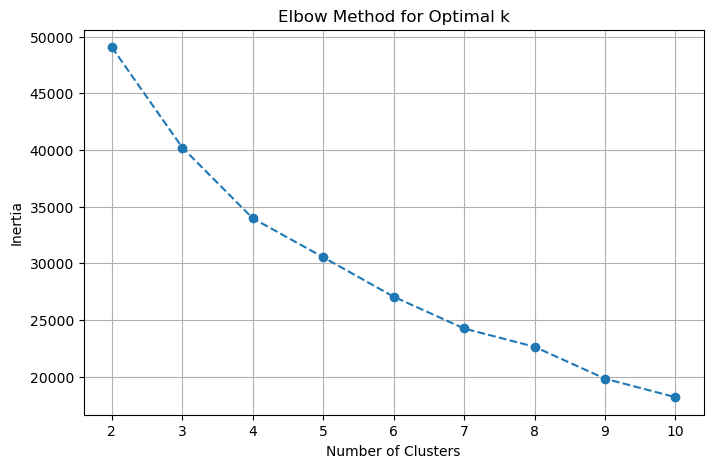

In [6]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

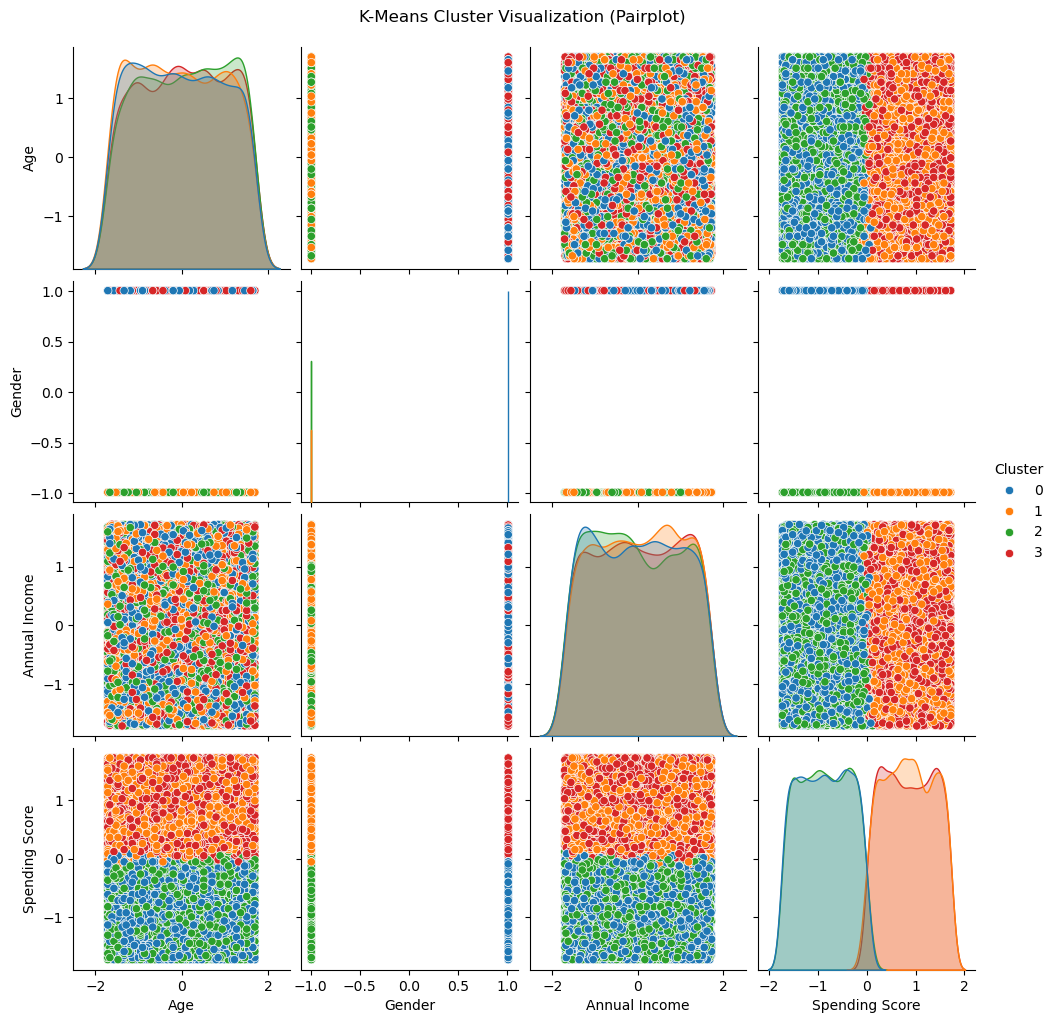

In [ ]:
# Model training and Visualization

# Applying K-Means with k=4 (assuming optimal from the elbow method)
df_scaled["Cluster"] = run_kmeans(df_scaled, k=4)

# Pair plot
sns.pairplot(df_mall_scaled, hue="Cluster", diag_kind="kde", palette="tab10")
plt.suptitle("K-Means Cluster Visualization (Pairplot)", y=1.02)
plt.show()

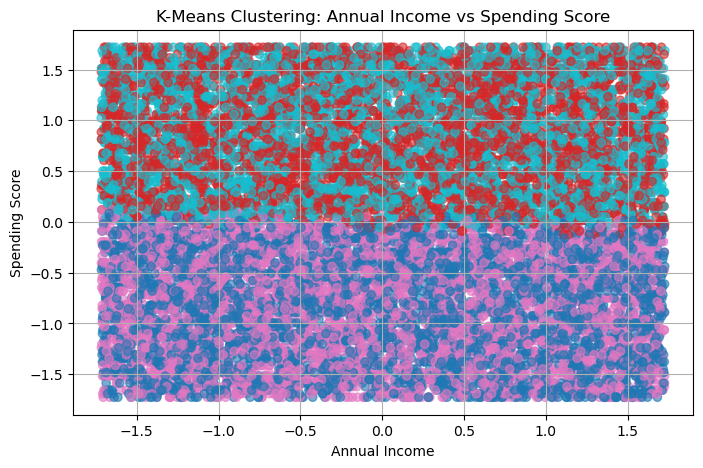

In [8]:
# K-Means Clustering scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_mall_scaled["Annual Income"],
    df_mall_scaled["Spending Score"],
    c=df_mall_scaled["Cluster"],
    cmap="tab10",
    alpha=0.6,
)
plt.title("K-Means Clustering: Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()


### Hierarchical Clustering

- Used Agglomerative Clustering with dendrogram analysis

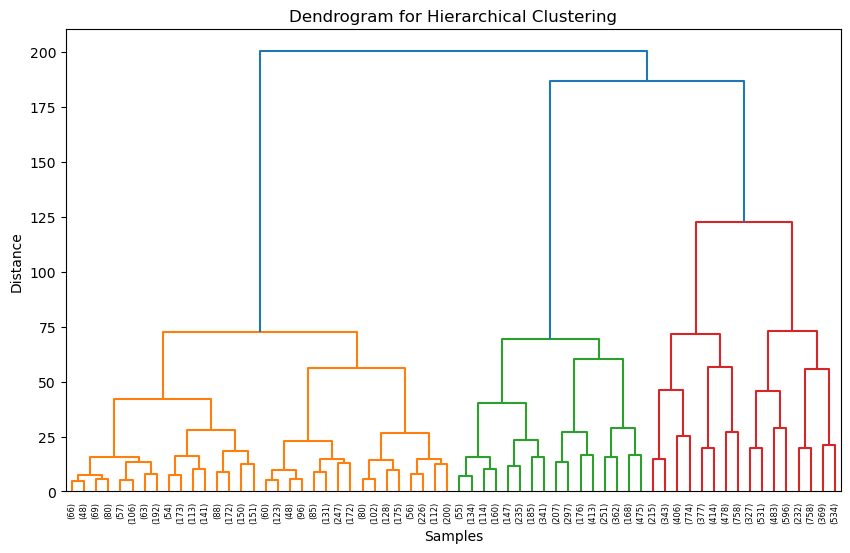

In [ ]:
# Generate linkage matrix for dendrogram
linked = linkage(df_mall_scaled, method="ward")

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [10]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
df_mall_scaled["Cluster_Hierarchical"] = agg.fit_predict(
    df_mall_scaled.drop(columns=["Cluster"])
)

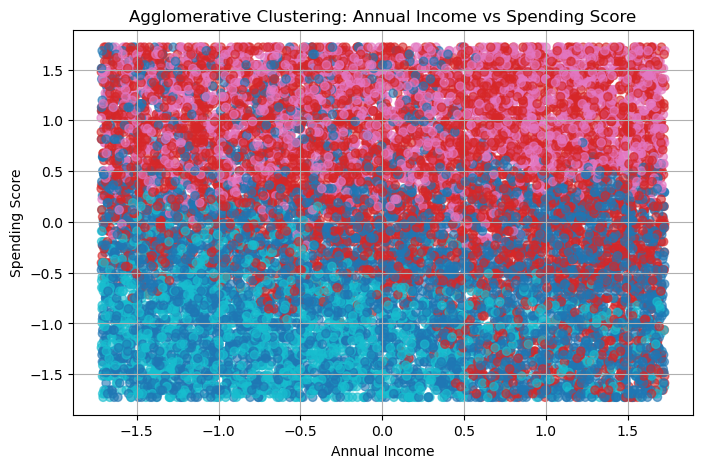

In [11]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_mall_scaled["Annual Income"],
    df_mall_scaled["Spending Score"],
    c=df_mall_scaled["Cluster_Hierarchical"],
    cmap="tab10",
    alpha=0.6,
)
plt.title("Agglomerative Clustering: Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()

### Evaluation & Visualization

- Visualized clusters using pair plots and 2D scatter plots  
- Evaluated models using:
    - Silhouette Score: higher is better
    - Davies-Bouldin Score: lower is better

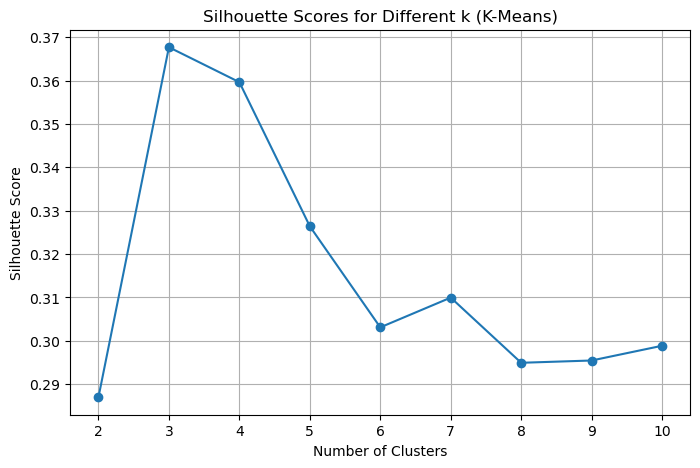

In [ ]:
# Calculate silhouette scores for different k values (2 to 10)
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(
        df_mall_scaled.drop(columns=["Cluster_Hierarchical"],
                            errors="ignore")
    )
    score = silhouette_score(
        df_mall_scaled.drop(columns=["Cluster_Hierarchical"],
                            errors="ignore"), labels
    )
    silhouette_scores.append(score)

# Plot silhouette scores for each k
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different k (K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

Optimal number of clusters based on silhouette score: 3


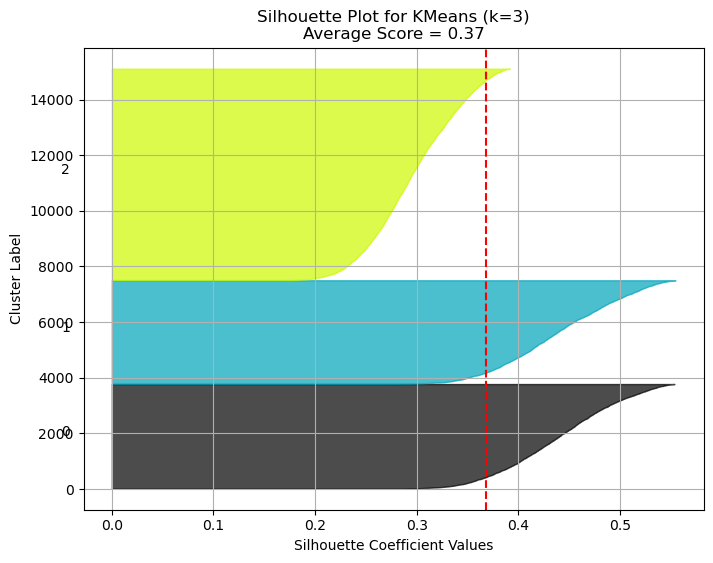

In [ ]:
# Select optimal k based on highest silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

# Fit KMeans model with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(
    df_mall_scaled.drop(columns=["Cluster_Hierarchical"],
                        errors="ignore")
)

# Compute silhouette values
sample_silhouette_values = silhouette_samples(
    df_mall_scaled.drop(columns=["Cluster_Hierarchical"],
                        errors="ignore"),
    cluster_labels,
)
silhouette_avg = np.mean(sample_silhouette_values)

# Plot silhouette visualization
y_lower = 10
plt.figure(figsize=(8, 6))

for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values
    [cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title(
    f"Silhouette Plot for KMeans (k={optimal_k})\n"
    f"Average Score = {silhouette_avg:.2f}"
)
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.grid(True)
plt.show()

In [ ]:
# KMeans Silhouette Score
score_kmeans = silhouette_score(
    df_mall_scaled.drop(columns=["Cluster_Hierarchical"],
                        errors="ignore"),
    df_mall_scaled["Cluster"],
)

# Hierarchical Silhouette Score
score_hier = silhouette_score(
    df_mall_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                        errors="ignore"),
    df_mall_scaled["Cluster_Hierarchical"],
)

print(f"Silhouette Score (KMeans, k=4): {score_kmeans:.4f}")
print(f"Silhouette Score (Agglomerative Clustering): {score_hier:.4f}")

Silhouette Score (KMeans, k=4): 0.3596
Silhouette Score (Agglomerative Clustering): 0.1697


In [ ]:
# Davies-Bouldin Score for KMeans
db_kmeans = davies_bouldin_score(
    df_mall_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                        errors="ignore"),
    df_mall_scaled["Cluster"],
)

# Davies-Bouldin Score for Agglomerative Clustering
db_hier = davies_bouldin_score(
    df_mall_scaled.drop(columns=["Cluster", "Cluster_Hierarchical"],
                        errors="ignore"),
    df_mall_scaled["Cluster_Hierarchical"],
)

print(f"Davies-Bouldin Score (KMeans, k=4): {db_kmeans:.4f}")
print(f"Davies-Bouldin Score (Agglomerative Clustering): {db_hier:.4f}")

Davies-Bouldin Score (KMeans, k=4): 1.6549
Davies-Bouldin Score (Agglomerative Clustering): 1.7927
